Import libraries

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras import layers, models
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

from sklearn.model_selection import train_test_split

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tensorflow.keras.callbacks import EarlyStopping

Get data

In [20]:
data_folder = '../data'

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_folder,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(256, 256),
    batch_size=64    
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_folder,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(256,256),
    batch_size=64
)

Found 3876 files belonging to 4 classes.
Using 3101 files for training.
Found 3876 files belonging to 4 classes.
Using 775 files for validation.


Check images

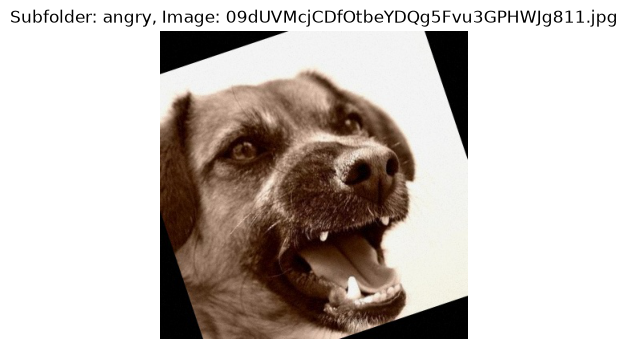

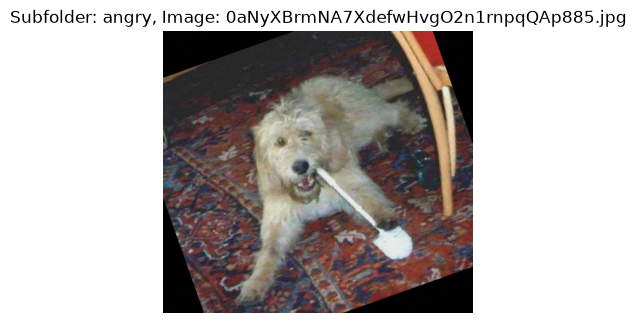

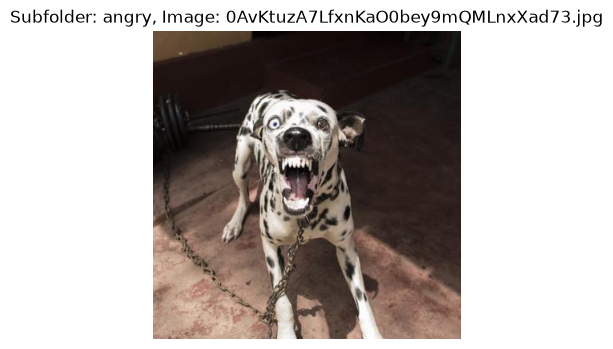

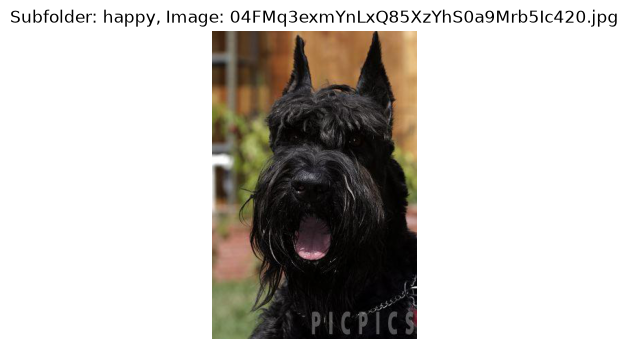

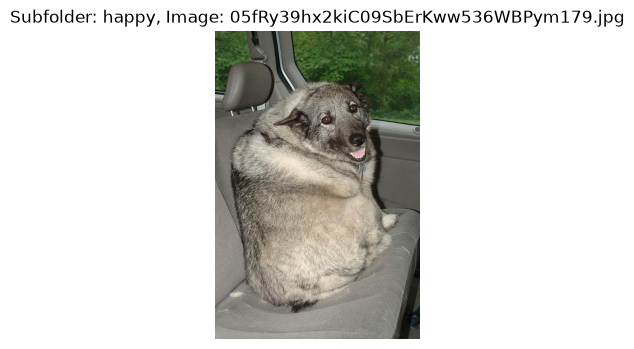

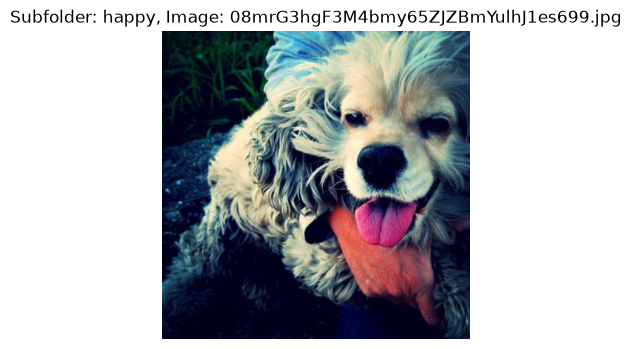

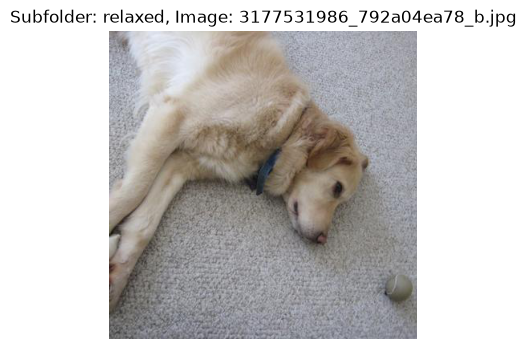

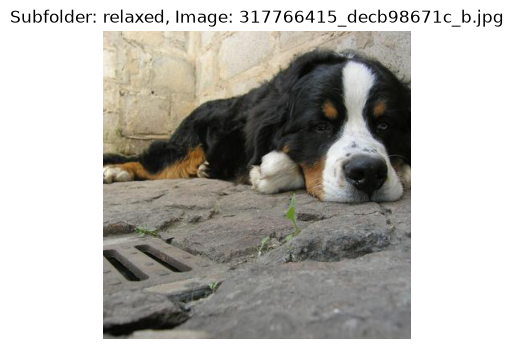

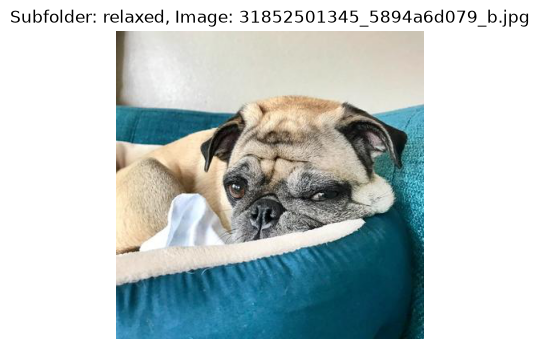

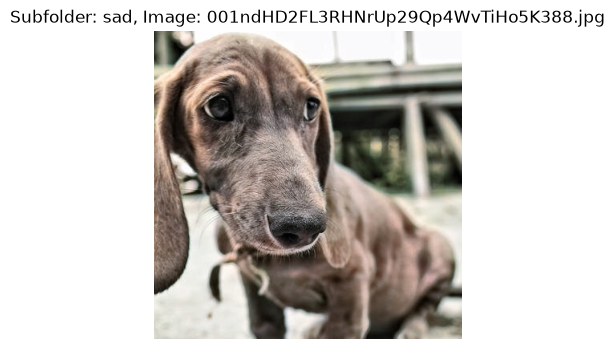

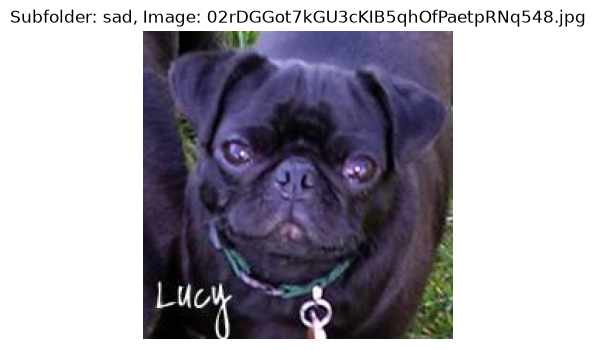

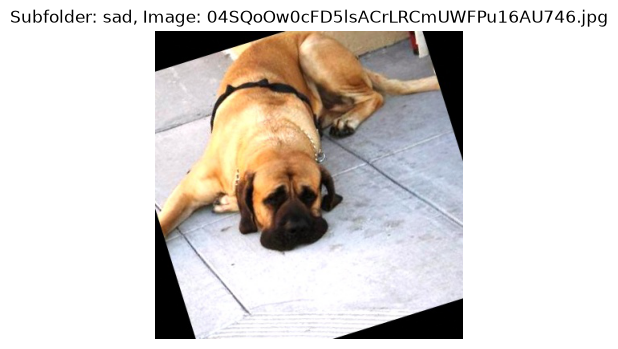

In [21]:
for subfolder in os.listdir(data_folder):
    subfolder_path = os.path.join(data_folder, subfolder)
    if os.path.isdir(subfolder_path):
        for image_file in os.listdir(subfolder_path)[:3]:
            image_path = os.path.join(subfolder_path, image_file)
            
            plt.figure(figsize=(4, 4)) 
            
            image = mpimg.imread(image_path)
            plt.imshow(image)
            plt.title(f'Subfolder: {subfolder}, Image: {image_file}')
            plt.axis('off')
            plt.show()

Data normalization

In [22]:
def process(image,label):
    image = tf.cast(image/255,tf.float32)
    return image,label
train_dataset = train_dataset.map(process)
validation_dataset = validation_dataset.map(process)

Model training

In [39]:
model = keras.Sequential([
    layers.InputLayer((256, 256, 3)),
    
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Conv2D(filters=20, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Conv2D(filters=20, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Flatten(),
    layers.Dense(4, activation='softmax')
])


In [40]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 254, 254, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 125, 125, 20)   │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 60, 60, 20)     │         3,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │        72,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,724 (303.61 KB)

 Trainable params: 77,724 (303.61 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(optimizer='adam', loss="SparseCategoricalCrossentropy", metrics=['accuracy'])

In [42]:
history = model.fit(train_dataset,
                    epochs=100, 
                    validation_data=validation_dataset,
                    callbacks=[EarlyStopping(patience=5)])

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step - accuracy: 0.3215 - loss: 1.3821 - val_accuracy: 0.4168 - val_loss: 1.2573
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.4779 - loss: 1.1670 - val_accuracy: 0.4452 - val_loss: 1.2348
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.5756 - loss: 1.0035 - val_accuracy: 0.4465 - val_loss: 1.2157
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - accuracy: 0.6501 - loss: 0.8773 - val_accuracy: 0.4335 - val_loss: 1.3235
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.7275 - loss: 0.7064 - val_accuracy: 0.4090 - val_loss: 1.4030
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step - accuracy: 0.7981 - loss: 0.5461 - val_accuracy: 0.4232 - val_loss: 1.6699
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step - accuracy: 0.8571 - loss: 0.4056 - val_accuracy: 0.4129 - val_loss: 1.8441
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step - accuracy: 0.9097 - loss: 0.2858 - val_accu

In [43]:
validation_loss, validation_accuracy = model.evaluate(validation_dataset)
print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.4206 - loss: 2.2475
Validation Loss: 2.2475035190582275
Validation Accuracy: 0.420645147562027


We have poor accuracy on self trained model, so lets fine-tun ResNet18 instead

In [44]:
from tensorflow.keras.applications.resnet50 import preprocess_input, ResNet50

In [53]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_folder,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224, 224),
    batch_size=64    
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_folder,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=64
)

Found 3876 files belonging to 4 classes.
Using 3101 files for training.
Found 3876 files belonging to 4 classes.
Using 775 files for validation.


In [48]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = preprocess_input(inputs)                # Normalises pixel values
x = ResNet50(include_top=False, weights='imagenet')(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(4, activation='softmax')(x)

fine_tuned_model = models.Model(inputs, outputs)

In [49]:
fine_tuned_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 224, 224)  │          0 │ input_layer_11[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 224, 224)  │          0 │ input_layer_11[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 224, 224)  │          0 │ input_layer_11[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item_6[0][0], │
│                     │ 3)                │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_14[0][0]      │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 4)         │      8,196 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 23,542,788 (89.81 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [54]:
fine_tuned_model.compile(optimizer='adam', loss="SparseCategoricalCrossentropy", metrics=['accuracy'])

In [55]:
history = fine_tuned_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=EarlyStopping(patience=5, restore_best_weights=True)
)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 443s 8s/step - accuracy: 0.6620 - loss: 0.9999 - val_accuracy: 0.3303 - val_loss: 52.5981
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 399s 8s/step - accuracy: 0.8259 - loss: 0.4549 - val_accuracy: 0.5948 - val_loss: 1.9633
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 394s 8s/step - accuracy: 0.9091 - loss: 0.2450 - val_accuracy: 0.6400 - val_loss: 1.7553
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 389s 8s/step - accuracy: 0.9123 - loss: 0.2489 - val_accuracy: 0.5948 - val_loss: 2.5616
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 379s 8s/step - accuracy: 0.9345 - loss: 0.1812 - val_accuracy: 0.6710 - val_loss: 1.5673
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 378s 8s/step - accuracy: 0.9465 - loss: 0.1615 - val_accuracy: 0.6645 - val_loss: 1.1516
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 378s 8s/step - accuracy: 0.9610 - loss: 0.1110 - val_accuracy: 0.7755 - val_loss: 0.8800
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 377s 8s/step - accuracy: 0.9694 - loss: 0.0922 - val_accuracy: 0.6942 - 

In [56]:
validation_loss, validation_accuracy = fine_tuned_model.evaluate(validation_dataset)
print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8103 - loss: 0.7276
Validation Loss: 0.7276172041893005
Validation Accuracy: 0.8103225827217102


Save weights

In [ ]:
fine_tuned_model.save('../saved_models/dog_emotion_resnet50.keras')
fine_tuned_model.save_weights('../saved_models/dog_emotion_resnet50.weights.h5')